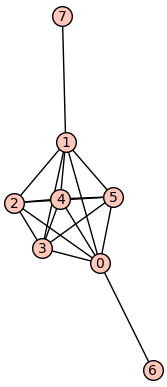

In [2]:
n = 6
Kn = graphs.CompleteGraph(n)
g = Kn
g.add_vertex(n)
g.add_vertex(n+1)
g.add_edge(0,n)
g.add_edge(1,n+1)

g.show()


In [1]:
def ch_co(G, filename) :
  n = G.order()
  m = G.size()
  spec_G = [round(x.real(),5) for x in sorted(G.spectrum())]

  for H in GraphsDatabase().read_graph6(filename):
    if H.order() != n or  H.size() != m :
      continue
    spec_H = [round(x.real().5) for x in sorted(G.spectrum())]
    if spec_H == spec_G :
      if not G.is_isomorphic(H) :
        print("Found cospectral mate!")
        return False
  return True

In [1]:
def create_G_n_k(n,k):
    Kn = graphs.CompleteGraph(n)
    g = Kn
    for i in range(k) :
        g.add_vertex(n+i)
        g.add_edge(i,n+i)
    return g


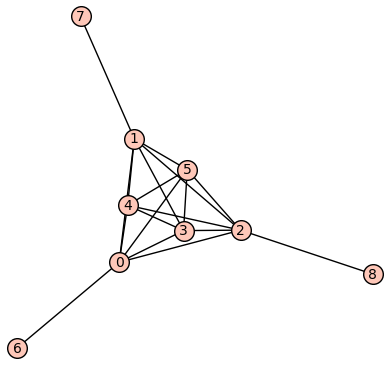

In [ ]:
g = create_G_n_k(6,3)
g.show()
ch_co(G, filename)

In [5]:
# print properties of G_n_k
def print_G_n_k(n,k) :
    G = create_G_n_k(n,k)
    # Get the Adjacency matrix
    A = G.adjacency_matrix()
    print("\nAdjajcency Matrix : \n")
    print(A)
    # Get spectrum
    spec = [round(x.real(), 5) for x in sorted(G.spectrum())]
    print("\nAdjaceency Spectrum : \n", spec)

    # Get the eigen vectors
    # Get the data
    eigvecs = G.eigenvectors()

    print(f"\n{'Eigenvalue':<15} | {'Mult':<5} | {'Eigenvectors'}")
    print("-" * 60)

    for value, vectors, mult in eigvecs:
        val = round(float(value.n()), 5)
        # Print the Eigenvalue and Multiplicity
        print(f"{str(val):<15} | {mult:<5} | ", end="")
        
        # Print the vectors (indented if there are multiple)
        first = True
        for v in vectors:
            if not first:
                print(f"{'':<15} | {'':<5} | ", end="") # Empty spacing for alignment
            
            vec = [round(float(x.n()), 4) for x in v]
            print(f"{vec}")
            first = False
        
        print("-" * 60) # Separator line

In [6]:
for k in range(2,11) :
    print_G_n_k(10,k)


Adjajcency Matrix : 

[0 1 1 1 1 1 1 1 1 1 1 0]
[1 0 1 1 1 1 1 1 1 1 0 1]
[1 1 0 1 1 1 1 1 1 1 0 0]
[1 1 1 0 1 1 1 1 1 1 0 0]
[1 1 1 1 0 1 1 1 1 1 0 0]
[1 1 1 1 1 0 1 1 1 1 0 0]
[1 1 1 1 1 1 0 1 1 1 0 0]
[1 1 1 1 1 1 1 0 1 1 0 0]
[1 1 1 1 1 1 1 1 0 1 0 0]
[1 1 1 1 1 1 1 1 1 0 0 0]
[1 0 0 0 0 0 0 0 0 0 0 0]
[0 1 0 0 0 0 0 0 0 0 0 0]

Adjaceency Spectrum : 
 [-1.61803, -1.52959, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, 0.50723, 0.61803, 9.02237]

Eigenvalue      | Mult  | Eigenvectors
------------------------------------------------------------
-1.0            | 7     | [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0]
                |       | [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0]
                |       | [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0]
                |       | [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, -1.0, 0.0, 0.0]
                |       | [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, -1.0, 0.0, 0.0]
         

In [7]:
from collections import Counter
def check_eigenvalues_in_range(values, min_val, max_val):
    """
    Prints eigenvalues of G that fall strictly within [min_val, max_val].
    To check for a single number like -2, use a tight range: min_val=-2.001, max_val=-1.999
    """
    # print(f"\nChecking range [{min_val}, {max_val}]...")
    # print(f"{'Eigenvalue':<15} | {'Mult':<5} | {'Eigenvectors (Rounded)'}")
    # print("-" * 80)

    
    # 1. Get all eigenvalues (Spectrum) - Faster than .eigenvectors()
    raw_spectrum = values

    # 2. Clean and Round the data
    # We round to 5 decimal places to handle float errors (e.g., -1.99999 -> -2.0)
    cleaned_spectrum = [round(float(x.n()), 5) for x in raw_spectrum]

    # 3. Count frequencies (Multiplicity)
    # This turns [-2, -2, 0] into {-2: 2, 0: 1}
    spectrum_counts = Counter(cleaned_spectrum)

    # 4. Filter and Print
    found_any = False
    
    # Sort keys so they print in order
    for val in sorted(spectrum_counts.keys()):
        mult = spectrum_counts[val]
        # Check range with slight tolerance
        if min_val - 1e-5 <= val <= max_val + 1e-5 and mult == 1:
            #mult = spectrum_counts[val]
            #print(f"{str(val):<15} | {mult:<5}")
            found_any = True
            return True

    if not found_any:
        print("Dose not found any : ", cleaned_spectrum)
        return False



    # found_any = False
    # eigvecs = vect

    # for value, vectors, mult in eigvecs:
        # Convert symbolic/complex to float for comparison
        # .n() evaluates it, float() makes it a Python number
        # val = float(value.n())
        
        # 🟢 THE FILTER LOGIC
        # We use a small tolerance (1e-5) to catch numbers that are "basically" on the edge
        # e.g., if you ask for range (-2, -2), it catches -2.0
        # if (min_val - 1e-5 <= val <= max_val + 1e-5) and mult == 1:
        #     found_any = True
        #     return true
            # Round for pretty printing
            # val_print = round(val, 5)
            
            # Print the Eigenvalue and Multiplicity
            # print(f"{str(val_print):<15} | {mult:<5} | ", end="")
            
            # Print the vectors
            # first = True
            # for v in vectors:
            #    if not first:
            #        print(f"{'':<15} | {'':<5} | ", end="")
                
                # Round vector elements
            #    rounded_v = [round(float(x.n()), 4) for x in v]
            #    print(tuple(rounded_v))
            
            
            # print("-" * 80)

    # if not found_any:
    #     print(f"{'No eigenvalues found in this range.':<15}")
    #     return false



In [8]:
count = 0
ch = False # false -> no eigenvalues, true -> therer is an eigen value
for i in range(6,40):
    for j in range(1,i):
        g = create_G_n_k(i,j)
        eig = g.spectrum()
        check = check_eigenvalues_in_range(eig, -2, -1) # lm1 -> (n-1, n) | lm2 -> (0,1) | lm3 -> (-2,-1)
        if check == ch:
            count = count + 1
            g.show()
            print(i)
            print(g.spectrum())
            break
    if count == 1:
            break  

print("count : ", count)
print("i : ", i, "\nj : ", j)
  


count :  0
i :  39 
j :  38


In [9]:
count = 0
for i in range(6,500):
    
    g = create_G_n_k(i,i)
    eig = g.spectrum()
    check = check_eigenvalues_in_range(eig, 0, 1)
    if check == false:
        count = count + 1

print("count : ", count)
print("i : ", i)
  


Dose not found any :  [5.19258, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, -0.19258, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803]
Dose not found any :  [6.16228, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, -0.16228, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803]
Dose not found any :  [7.14005, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, -0.14005, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803]
Dose not found any :  [8.12311, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, -0.12311, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803]
Dose not found any :  [9.10977, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, -0.10977, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803]
Dose not found any :  [10.09902, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, -0

KeyboardInterrupt: 

In [ ]:
s = -1.61803
for i in range(0,11):
    
    g = create_G_n_k(10,i)
    eig = g.spectrum()
    
     # 1. Get all eigenvalues (Spectrum) - Faster than .eigenvectors()
    raw_spectrum = eig

    # 2. Clean and Round the data
    # We round to 5 decimal places to handle float errors (e.g., -1.99999 -> -2.0)
    cleaned_spectrum = [round(float(x.n()), 5) for x in raw_spectrum]

    # 3. Count frequencies (Multiplicity)
    # This turns [-2, -2, 0] into {-2: 2, 0: 1}
    spectrum_counts = Counter(cleaned_spectrum)
    print(cleaned_spectrum)
    print("for k = ", i, f" multiplicity of {round(s,5)} : ", spectrum_counts[s])

[9.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0]
for k =  0  multiplicity of -1.61803 :  0
[9.01121, 0.5637, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.57491]
for k =  1  multiplicity of -1.61803 :  0
[9.02237, 0.61803, 0.50723, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.52959, -1.61803]
for k =  2  multiplicity of -1.61803 :  1
[9.03347, 0.61803, 0.61803, 0.44826, -1.0, -1.0, -1.0, -1.0, -1.0, -1.0, -1.48173, -1.61803, -1.61803]
for k =  3  multiplicity of -1.61803 :  2
[9.04452, 0.61803, 0.61803, 0.61803, 0.38635, -1.0, -1.0, -1.0, -1.0, -1.0, -1.43087, -1.61803, -1.61803, -1.61803]
for k =  4  multiplicity of -1.61803 :  3
[9.05552, 0.61803, 0.61803, 0.61803, 0.61803, 0.32092, -1.0, -1.0, -1.0, -1.0, -1.37644, -1.61803, -1.61803, -1.61803, -1.61803]
for k =  5  multiplicity of -1.61803 :  4
[9.06647, 0.61803, 0.61803, 0.61803, 0.61803, 0.61803, 0.25113, -1.0, -1.0, -1.0, -1.3176, -1.61803, -1.61803, -1.61803, -1.61803, -1.61803]
for k =  6  multiplicity of -1.61